In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jananowakova/retinal-image-dataset-of-infants-and-rop/infant_retinal_database_info.csv
/kaggle/input/datasets/jananowakova/retinal-image-dataset-of-infants-and-rop/infant_retinal_database_info.xlsx
/kaggle/input/datasets/jananowakova/retinal-image-dataset-of-infants-and-rop/images_stack_without_captions/images_stack_without_captions/019_M_GA35_BW3050_PA46_DG11_PF0_D1_S03_3.jpg
/kaggle/input/datasets/jananowakova/retinal-image-dataset-of-infants-and-rop/images_stack_without_captions/images_stack_without_captions/164_F_GA30_BW1490_PA32_DG0_PF0_D3_S01_2.jpg
/kaggle/input/datasets/jananowakova/retinal-image-dataset-of-infants-and-rop/images_stack_without_captions/images_stack_without_captions/120_M_GA31_BW1670_PA39_DG0_PF0_D2_S03_15.jpg
/kaggle/input/datasets/jananowakova/retinal-image-dataset-of-infants-and-rop/images_stack_without_captions/images_stack_without_captions/138_F_GA26_BW680_PA35_DG3_PF2_D2_S03_5.jpg
/kaggle/input/datasets/jananowakova/retinal-image-data

In [2]:
import os, glob, random, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, cohen_kappa_score)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
for i in range(torch.cuda.device_count()):
    p = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}: {p.name} | {p.total_memory/1e9:.1f} GB")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print("Ready.")

Device : cuda
  GPU 0: Tesla T4 | 15.6 GB
  GPU 1: Tesla T4 | 15.6 GB
Ready.


In [3]:
class CFG:
    DATA_DIR  = '/kaggle/input/datasets/jananowakova/retinal-image-dataset-of-infants-and-rop'
    IMAGE_DIR = f'{DATA_DIR}/images_stack_without_captions/images_stack_without_captions'
    IMG_SIZE  = 224          # smaller = faster, no alignment issues
    IMG_EXT   = '.jpg'

    CNN_DIM   = 512          # EfficientNet-B3 output
    VIT_DIM   = 512          # SwinTiny output
    FUSED_DIM = 1024
    CTAF_DIM  = 256
    META_DIM  = 3
    DROPOUT   = 0.4

    N_STAGES  = 4
    N_ZONES   = 3
    N_PLUS    = 2            # binary: 0=no plus, 1=plus

    BATCH_SIZE = 32
    EPOCHS     = 30
    LR         = 2e-4
    PATIENCE   = 8

    STAGE_WEIGHTS = None
    ZONE_WEIGHTS  = None
    PLUS_WEIGHTS  = None

CFG = CFG()
print(f"Image size : {CFG.IMG_SIZE}x{CFG.IMG_SIZE}")
print(f"Batch size : {CFG.BATCH_SIZE}")
print(f"Device     : {device}")

Image size : 224x224
Batch size : 32
Device     : cuda


In [4]:
import re

all_images = sorted(glob.glob(CFG.IMAGE_DIR + '/*.jpg'))
print(f"Total images: {len(all_images)}")

def parse_filename(path):
    name = os.path.splitext(os.path.basename(path))[0]
    r = {'filepath': path, 'filename': os.path.basename(path)}
    for p in name.split('_'):
        if p in ('M','F'):           r['sex'] = 0 if p=='M' else 1
        elif p.startswith('GA'):     r['gestational_age'] = float(p[2:])
        elif p.startswith('BW'):     r['birth_weight']    = float(p[2:])
        elif p.startswith('PA'):     r['patient_id']      = p[2:]
        elif p.startswith('DG'):     r['dg_raw']          = p[2:]
        elif p.startswith('PF'):     r['plus_raw']        = int(p[2:])
        elif p.startswith('D') and len(p)==2 and p[1].isdigit():
                                     r['zone_raw']        = int(p[1:])
    return r

df = pd.DataFrame([parse_filename(p) for p in all_images])

def map_stage(dg):
    d = str(dg)[0]
    return {'0':0,'1':1,'2':2,'3':3,'8':3,'9':3}.get(d, 0)

df['stage_label'] = df['dg_raw'].apply(map_stage)
df['zone_label']  = df['zone_raw'].apply(lambda x: int(x)-1)
df['plus_label']  = df['plus_raw'].apply(lambda x: 1 if int(x)>=2 else 0)

for col in ['gestational_age','birth_weight','sex']:
    df[col] = (df[col] - df[col].mean()) / (df[col].std() + 1e-8)

df = df.dropna(subset=['stage_label','zone_label','plus_label',
                        'patient_id','filepath']).reset_index(drop=True)

print(f"Dataset: {len(df)} images | {df['patient_id'].nunique()} patients")
print("Stage:\n", df['stage_label'].value_counts().sort_index())
print("Zone:\n",  df['zone_label'].value_counts().sort_index())
print("Plus:\n",  df['plus_label'].value_counts().sort_index())

Total images: 6004
Dataset: 6004 images | 38 patients
Stage:
 stage_label
0    3105
1    1340
2     252
3    1307
Name: count, dtype: int64
Zone:
 zone_label
0    2578
1    2452
2     974
Name: count, dtype: int64
Plus:
 plus_label
0    5375
1     629
Name: count, dtype: int64


In [5]:
patients = df['patient_id'].unique()
np.random.shuffle(patients)

n_test  = max(2, int(len(patients)*0.10))
n_val   = max(2, int(len(patients)*0.10))

test_pats  = set(patients[:n_test])
val_pats   = set(patients[n_test:n_test+n_val])
train_pats = set(patients[n_test+n_val:])

df_train = df[df['patient_id'].isin(train_pats)].reset_index(drop=True)
df_val   = df[df['patient_id'].isin(val_pats)].reset_index(drop=True)
df_test  = df[df['patient_id'].isin(test_pats)].reset_index(drop=True)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

def class_weights(series, n):
    c = np.bincount(series.astype(int), minlength=n).astype(float)
    c = np.where(c==0, 1, c)
    return torch.tensor(len(series)/(n*c), dtype=torch.float32)

CFG.STAGE_WEIGHTS = class_weights(df_train['stage_label'], CFG.N_STAGES)
CFG.ZONE_WEIGHTS  = class_weights(df_train['zone_label'],  CFG.N_ZONES)
CFG.PLUS_WEIGHTS  = class_weights(df_train['plus_label'],  CFG.N_PLUS)

print("Stage w:", CFG.STAGE_WEIGHTS.numpy().round(3))
print("Zone  w:", CFG.ZONE_WEIGHTS.numpy().round(3))
print("Plus  w:", CFG.PLUS_WEIGHTS.numpy().round(3))

Train: 4925 | Val: 811 | Test: 268
Stage w: [0.501 1.081 6.917 1.069]
Zone  w: [0.753 0.826 2.166]
Plus  w: [0.569 4.111]


In [6]:
class ROPDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['filepath']).convert('RGB')
        except:
            img = Image.new('RGB', (CFG.IMG_SIZE, CFG.IMG_SIZE), 0)
        if self.transform:
            img = self.transform(img)
        meta  = torch.tensor([float(row['gestational_age']),
                               float(row['birth_weight']),
                               float(row['sex'])], dtype=torch.float32)
        stage = torch.tensor(int(row['stage_label']), dtype=torch.long)
        zone  = torch.tensor(int(row['zone_label']),  dtype=torch.long)
        plus  = torch.tensor(int(row['plus_label']),  dtype=torch.long)
        return img, meta, stage, zone, plus

MEAN = [0.485,0.456,0.406]
STD  = [0.229,0.224,0.225]

train_tf = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
val_tf = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_loader = DataLoader(ROPDataset(df_train, train_tf),
    batch_size=CFG.BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(ROPDataset(df_val,   val_tf),
    batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(ROPDataset(df_test,  val_tf),
    batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_loader)} batches")
print(f"Val  : {len(val_loader)} batches")
print(f"Test : {len(test_loader)} batches")

imgs, metas, s, z, p = next(iter(train_loader))
print(f"Batch shape: {imgs.shape} | Meta: {metas.shape}")

Train: 154 batches
Val  : 26 batches
Test : 9 batches
Batch shape: torch.Size([32, 3, 224, 224]) | Meta: torch.Size([32, 3])


In [7]:
class DualStreamBackbone(nn.Module):
    """
    Stream A: EfficientNet-B3 — local vessel texture
    Stream B: Swin-Tiny       — global context (T4-stable, no alignment issues)
    Output  : LayerNorm(concat) → (B, 1024)
    """
    def __init__(self):
        super().__init__()

        # ── Stream A: EfficientNet-B3 ─────────────────────────────────────────
        eff = models.efficientnet_b3(weights='IMAGENET1K_V1')
        in_eff = eff.classifier[1].in_features
        eff.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_eff, CFG.CNN_DIM),
            nn.GELU()
        )
        self.cnn = eff

        # ── Stream B: Swin-Tiny ───────────────────────────────────────────────
        swin = models.swin_t(weights='IMAGENET1K_V1')
        in_swin = swin.head.in_features
        swin.head = nn.Sequential(
            nn.Linear(in_swin, CFG.VIT_DIM),
            nn.GELU(),
            nn.Dropout(0.3)
        )
        self.vit = swin

        self.norm = nn.LayerNorm(CFG.FUSED_DIM)

    def forward(self, x):
        f_cnn = self.cnn(x)
        f_vit = self.vit(x)
        return self.norm(torch.cat([f_cnn, f_vit], dim=1)), f_cnn, f_vit

# Quick test
_b = DualStreamBackbone().to(device)
_x = torch.randn(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE, device=device)
with torch.no_grad():
    _o, _c, _v = _b(_x)
print(f"Fused: {_o.shape} | CNN: {_c.shape} | ViT: {_v.shape}")
del _b, _x, _o, _c, _v
torch.cuda.empty_cache()
print("Backbone OK.")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 202MB/s]


Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 189MB/s] 


Fused: torch.Size([2, 1024]) | CNN: torch.Size([2, 512]) | ViT: torch.Size([2, 512])
Backbone OK.


In [8]:
class CTAFModule(nn.Module):
    def __init__(self, dim=CFG.CTAF_DIM):
        super().__init__()
        self.scale  = dim ** -0.5
        self.norm_s = nn.LayerNorm(dim)
        self.norm_z = nn.LayerNorm(dim)
        self.norm_p = nn.LayerNorm(dim)

    def _attend(self, q, keys):
        K = torch.stack(keys, dim=1)
        w = F.softmax(torch.bmm(q.unsqueeze(1),
                      K.transpose(1,2)) * self.scale, dim=-1)
        return torch.bmm(w, K).squeeze(1)

    def forward(self, Hs, Hz, Hp):
        return (self.norm_s(Hs + self._attend(Hs, [Hz, Hp])),
                self.norm_z(Hz + self._attend(Hz, [Hs, Hp])),
                self.norm_p(Hp + self._attend(Hp, [Hs, Hz])))

_c = CTAFModule().to(device)
_h = [torch.randn(4, CFG.CTAF_DIM, device=device) for _ in range(3)]
with torch.no_grad():
    fs, fz, fp = _c(*_h)
print(f"CTAF: {fs.shape} {fz.shape} {fp.shape}")
del _c, _h, fs, fz, fp
print("CTAF OK.")

CTAF: torch.Size([4, 256]) torch.Size([4, 256]) torch.Size([4, 256])
CTAF OK.


In [9]:
class MetadataGate(nn.Module):
    def __init__(self, feat_dim=CFG.CTAF_DIM, meta_dim=CFG.META_DIM):
        super().__init__()
        self.gate      = nn.Sequential(
            nn.Linear(feat_dim + meta_dim, feat_dim), nn.Sigmoid())
        self.meta_proj = nn.Sequential(
            nn.Linear(meta_dim, feat_dim), nn.GELU())
        self.norm = nn.LayerNorm(feat_dim)

    def forward(self, feat, meta):
        g = self.gate(torch.cat([feat, meta], dim=1))
        return self.norm(g * feat + (1-g) * self.meta_proj(meta))

_g = MetadataGate().to(device)
_f = torch.randn(4, CFG.CTAF_DIM, device=device)
_m = torch.randn(4, CFG.META_DIM, device=device)
with torch.no_grad():
    _o = _g(_f, _m)
print(f"Gate output: {_o.shape}")
del _g, _f, _m, _o
print("MetadataGate OK.")

Gate output: torch.Size([4, 256])
MetadataGate OK.


In [10]:
class MTL_CTAF_ROP(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone   = DualStreamBackbone()
        proj = lambda: nn.Sequential(
            nn.Linear(CFG.FUSED_DIM, 512), nn.GELU(), nn.Dropout(CFG.DROPOUT),
            nn.Linear(512, CFG.CTAF_DIM),  nn.GELU())
        self.proj_s     = proj()
        self.proj_z     = proj()
        self.proj_p     = proj()
        self.ctaf       = CTAFModule()
        self.gate_s     = MetadataGate()
        self.gate_z     = MetadataGate()
        self.gate_p     = MetadataGate()
        self.drop       = nn.Dropout(CFG.DROPOUT)
        self.clf_stage  = nn.Linear(CFG.CTAF_DIM, CFG.N_STAGES)
        self.clf_zone   = nn.Linear(CFG.CTAF_DIM, CFG.N_ZONES)
        self.clf_plus   = nn.Linear(CFG.CTAF_DIM, CFG.N_PLUS)

    def forward(self, x, meta):
        fused, _, _ = self.backbone(x)
        Hs = self.proj_s(fused)
        Hz = self.proj_z(fused)
        Hp = self.proj_p(fused)
        Fs, Fz, Fp = self.ctaf(Hs, Hz, Hp)
        Fs = self.gate_s(self.drop(Fs), meta)
        Fz = self.gate_z(self.drop(Fz), meta)
        Fp = self.gate_p(self.drop(Fp), meta)
        return (self.clf_stage(self.drop(Fs)),
                self.clf_zone(self.drop(Fz)),
                self.clf_plus(self.drop(Fp)))

model = MTL_CTAF_ROP().to(device)
print(f"Params: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")

_x = torch.randn(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE, device=device)
_m = torch.randn(2, CFG.META_DIM, device=device)
with torch.no_grad():
    ls, lz, lp = model(_x, _m)
print(f"Stage:{ls.shape} Zone:{lz.shape} Plus:{lp.shape}")
del _x, _m, ls, lz, lp
torch.cuda.empty_cache()
print("Model OK. Ready for training.")

Params: 41.57 M
Stage:torch.Size([2, 4]) Zone:torch.Size([2, 3]) Plus:torch.Size([2, 2])
Model OK. Ready for training.


In [11]:
class UncertaintyWeightedLoss(nn.Module):
    def __init__(self, n=3):
        super().__init__()
        self.log_sigma = nn.Parameter(torch.zeros(n))
    def forward(self, losses):
        total = sum(torch.exp(-self.log_sigma[i])*L + self.log_sigma[i]
                    for i, L in enumerate(losses))
        return total

criterion_stage = nn.CrossEntropyLoss(weight=CFG.STAGE_WEIGHTS.to(device))
criterion_zone  = nn.CrossEntropyLoss(weight=CFG.ZONE_WEIGHTS.to(device))
criterion_plus  = nn.CrossEntropyLoss(weight=CFG.PLUS_WEIGHTS.to(device))
unc_loss        = UncertaintyWeightedLoss().to(device)

print("Loss ready. log_sigma:", unc_loss.log_sigma.cpu().data.numpy())

Loss ready. log_sigma: [0. 0. 0.]


In [12]:
optimizer = torch.optim.Adam(
    list(model.parameters()) + list(unc_loss.parameters()),
    lr=CFG.LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG.EPOCHS, eta_min=1e-6)
scaler = torch.cuda.amp.GradScaler()
print("Optimizer ready.")

Optimizer ready.


In [13]:
def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    tot_loss = cs = cz = cp = n = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, metas, sl, zl, pl in loader:
            imgs  = imgs.to(device);  metas = metas.to(device)
            sl    = sl.to(device);    zl    = zl.to(device);  pl = pl.to(device)
            if train: optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                ls, lz, lp = model(imgs, metas)
                loss = unc_loss([criterion_stage(ls, sl),
                                 criterion_zone(lz, zl),
                                 criterion_plus(lp, pl)])
            if train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update()
            b = imgs.size(0); n += b; tot_loss += loss.item()*b
            cs += (ls.argmax(1)==sl).sum().item()
            cz += (lz.argmax(1)==zl).sum().item()
            cp += (lp.argmax(1)==pl).sum().item()
    return dict(loss=tot_loss/n, stage=cs/n, zone=cz/n, plus=cp/n)

best_loss, patience_cnt = float('inf'), 0
history = []

print(f"{'Ep':>3} | {'TrLoss':>7} {'TrStg':>6} {'TrPls':>6} | "
      f"{'VaLoss':>7} {'VaStg':>6} {'VaPls':>6}")
print("─"*55)

for ep in range(1, CFG.EPOCHS+1):
    tr = run_epoch(model, train_loader, train=True)
    va = run_epoch(model, val_loader,   train=False)
    scheduler.step()
    history.append({'tr':tr,'va':va})

    print(f"{ep:3d} | {tr['loss']:7.4f} {tr['stage']:6.3f} {tr['plus']:6.3f} | "
          f"{va['loss']:7.4f} {va['stage']:6.3f} {va['plus']:6.3f}", end="")

    if va['loss'] < best_loss:
        best_loss = va['loss']
        patience_cnt = 0
        torch.save({'model': model.state_dict(),
                    'unc':   unc_loss.state_dict(),
                    'ep':    ep}, '/kaggle/working/best.pth')
        print("  ✓")
    else:
        patience_cnt += 1
        print()
        if patience_cnt >= CFG.PATIENCE:
            print(f"Early stop at epoch {ep}"); break

print(f"\nBest val loss: {best_loss:.4f}")

 Ep |  TrLoss  TrStg  TrPls |  VaLoss  VaStg  VaPls
───────────────────────────────────────────────────────
  1 |  1.4801  0.594  0.891 |  1.2106  0.719  0.957  ✓
  2 |  0.6932  0.777  0.973 |  0.8152  0.740  0.990  ✓
  3 |  0.3621  0.845  0.986 |  1.0245  0.726  0.986
  4 |  0.1508  0.879  0.991 |  1.0720  0.729  0.996
  5 | -0.0160  0.898  0.994 |  0.9490  0.737  0.990
  6 | -0.1743  0.928  0.993 |  1.3839  0.755  0.979
  7 | -0.3536  0.938  0.996 |  1.2295  0.810  0.985
  8 | -0.4479  0.951  0.997 |  1.3396  0.778  0.989
  9 | -0.5852  0.963  0.999 |  1.2187  0.793  0.994
 10 | -0.6837  0.968  0.999 |  1.6296  0.764  0.994
Early stop at epoch 10

Best val loss: 0.8152


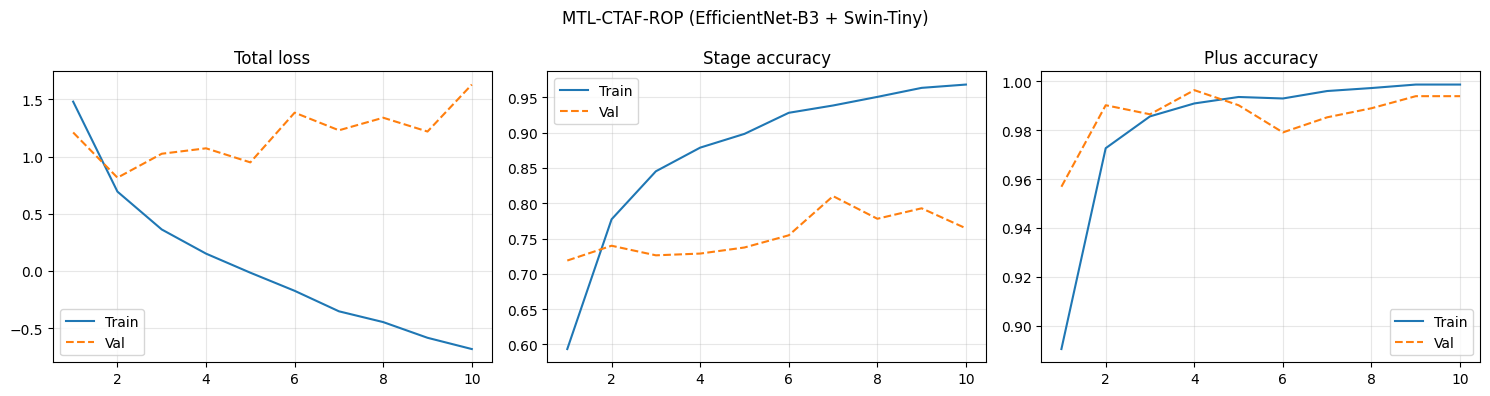

In [14]:
#CELL 14 (CURVES)

n = len(history)
xs = range(1, n+1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes,
        ['loss','stage','plus'],
        ['Total loss','Stage accuracy','Plus accuracy']):
    ax.plot(xs, [h['tr'][key] for h in history], label='Train')
    ax.plot(xs, [h['va'][key] for h in history], label='Val', linestyle='--')
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('MTL-CTAF-ROP (EfficientNet-B3 + Swin-Tiny)')
plt.tight_layout()
plt.savefig('/kaggle/working/curves.png', dpi=120)
plt.show()

Loaded best model from epoch 2

FINAL TEST RESULTS
Stage accuracy : 90.30%
Zone  accuracy : 100.00%
Plus  accuracy : 100.00%

── STAGE Classification Report ──
              precision    recall  f1-score   support

     Stage 0     0.7685    1.0000    0.8691        83
     Stage 1     1.0000    0.9652    0.9823       115
     Stage 2     1.0000    0.3750    0.5455        24
     Stage 3     0.9750    0.8478    0.9070        46

    accuracy                         0.9030       268
   macro avg     0.9359    0.7970    0.8260       268
weighted avg     0.9240    0.9030    0.8952       268



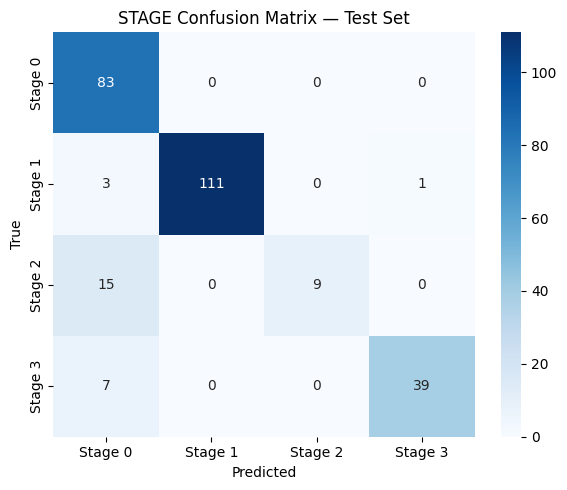


── ZONE Classification Report ──
              precision    recall  f1-score   support

      Zone I     1.0000    1.0000    1.0000       138
     Zone II     1.0000    1.0000    1.0000        83
    Zone III     1.0000    1.0000    1.0000        47

    accuracy                         1.0000       268
   macro avg     1.0000    1.0000    1.0000       268
weighted avg     1.0000    1.0000    1.0000       268



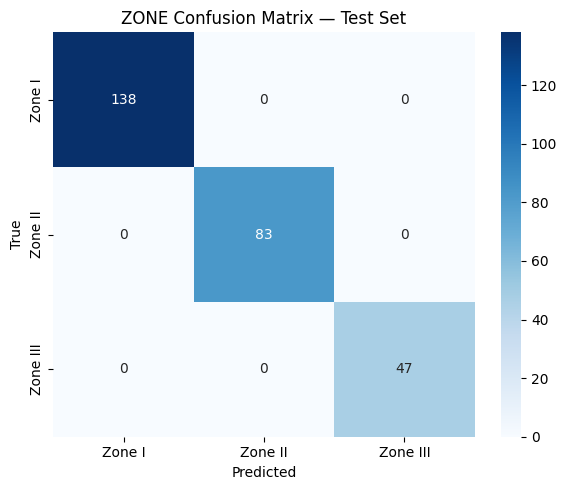


── PLUS DISEASE Classification Report ──
              precision    recall  f1-score   support

     No Plus     1.0000    1.0000    1.0000       254
        Plus     1.0000    1.0000    1.0000        14

    accuracy                         1.0000       268
   macro avg     1.0000    1.0000    1.0000       268
weighted avg     1.0000    1.0000    1.0000       268



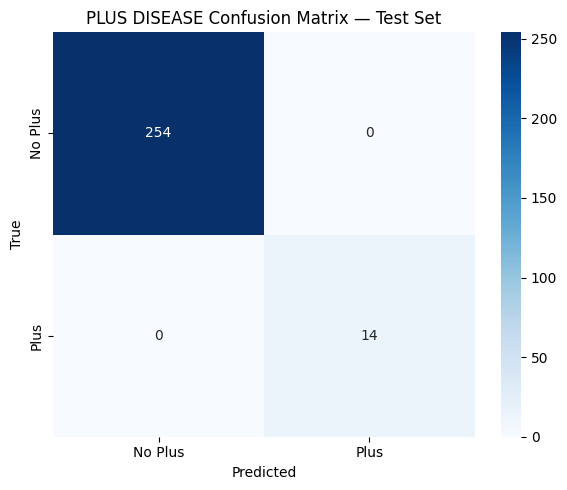


── AUC Scores ──
Stage     : AUC = 0.9793
Zone      : AUC = 1.0000
Plus      : AUC = 1.0000

── Cohen's Kappa ──
Stage : κ = 0.8550
Zone  : κ = 1.0000
Plus  : κ = 1.0000

All results saved to /kaggle/working/


In [15]:
# ── CELL 15 : Test Evaluation ─────────────────────────────────────────────────

ckpt = torch.load('/kaggle/working/best.pth', map_location=device)
model.load_state_dict(ckpt['model'])
print(f"Loaded best model from epoch {ckpt['ep']}")

model.eval()
all_ls, all_lz, all_lp = [], [], []
all_sl, all_zl, all_pl = [], [], []

with torch.no_grad():
    for imgs, metas, sl, zl, pl in test_loader:
        imgs  = imgs.to(device)
        metas = metas.to(device)
        ls, lz, lp = model(imgs, metas)
        all_ls.append(ls.argmax(1).cpu())
        all_lz.append(lz.argmax(1).cpu())
        all_lp.append(lp.argmax(1).cpu())
        all_sl.append(sl)
        all_zl.append(zl)
        all_pl.append(pl)

pred_s = torch.cat(all_ls).numpy()
pred_z = torch.cat(all_lz).numpy()
pred_p = torch.cat(all_lp).numpy()
true_s = torch.cat(all_sl).numpy()
true_z = torch.cat(all_zl).numpy()
true_p = torch.cat(all_pl).numpy()

# ── Overall accuracy ──────────────────────────────────────────────────────────
print("\n" + "="*50)
print("FINAL TEST RESULTS")
print("="*50)
print(f"Stage accuracy : {(pred_s==true_s).mean()*100:.2f}%")
print(f"Zone  accuracy : {(pred_z==true_z).mean()*100:.2f}%")
print(f"Plus  accuracy : {(pred_p==true_p).mean()*100:.2f}%")
print("="*50)

# ── Per class reports ─────────────────────────────────────────────────────────
stage_names = ['Stage 0','Stage 1','Stage 2','Stage 3']
zone_names  = ['Zone I','Zone II','Zone III']
plus_names  = ['No Plus','Plus']

for preds, trues, names, title in [
    (pred_s, true_s, stage_names, 'STAGE'),
    (pred_z, true_z, zone_names,  'ZONE'),
    (pred_p, true_p, plus_names,  'PLUS DISEASE'),
]:
    print(f"\n── {title} Classification Report ──")
    print(classification_report(trues, preds, target_names=names, digits=4))

    cm = confusion_matrix(trues, preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=names, yticklabels=names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{title} Confusion Matrix — Test Set')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/cm_{title.lower().replace(" ","_")}.png', dpi=150)
    plt.show()

# ── AUC ───────────────────────────────────────────────────────────────────────
print("\n── AUC Scores ──")
from sklearn.preprocessing import label_binarize

for trues, names, title in [
    (true_s, stage_names, 'Stage'),
    (true_z, zone_names,  'Zone'),
]:
    try:
        n = len(names)
        tb = label_binarize(trues, classes=list(range(n)))
        # need probabilities — re-run with softmax
        probs = []
        model.eval()
        with torch.no_grad():
            for imgs, metas, sl, zl, pl in test_loader:
                imgs = imgs.to(device); metas = metas.to(device)
                ls, lz, lp = model(imgs, metas)
                if title == 'Stage':
                    probs.append(F.softmax(ls, dim=1).cpu())
                else:
                    probs.append(F.softmax(lz, dim=1).cpu())
        probs = torch.cat(probs).numpy()
        auc = roc_auc_score(tb, probs, multi_class='ovr', average='macro')
        print(f"{title:10}: AUC = {auc:.4f}")
    except Exception as e:
        print(f"{title:10}: AUC failed — {e}")

# Plus AUC (binary)
try:
    plus_probs = []
    model.eval()
    with torch.no_grad():
        for imgs, metas, sl, zl, pl in test_loader:
            imgs = imgs.to(device); metas = metas.to(device)
            ls, lz, lp = model(imgs, metas)
            plus_probs.append(F.softmax(lp, dim=1).cpu())
    plus_probs = torch.cat(plus_probs).numpy()[:, 1]
    auc = roc_auc_score(true_p, plus_probs)
    print(f"{'Plus':10}: AUC = {auc:.4f}")
except Exception as e:
    print(f"Plus AUC failed — {e}")

# ── Cohen Kappa ───────────────────────────────────────────────────────────────
print("\n── Cohen's Kappa ──")
print(f"Stage : κ = {cohen_kappa_score(true_s, pred_s):.4f}")
print(f"Zone  : κ = {cohen_kappa_score(true_z, pred_z):.4f}")
print(f"Plus  : κ = {cohen_kappa_score(true_p, pred_p):.4f}")

print("\nAll results saved to /kaggle/working/")

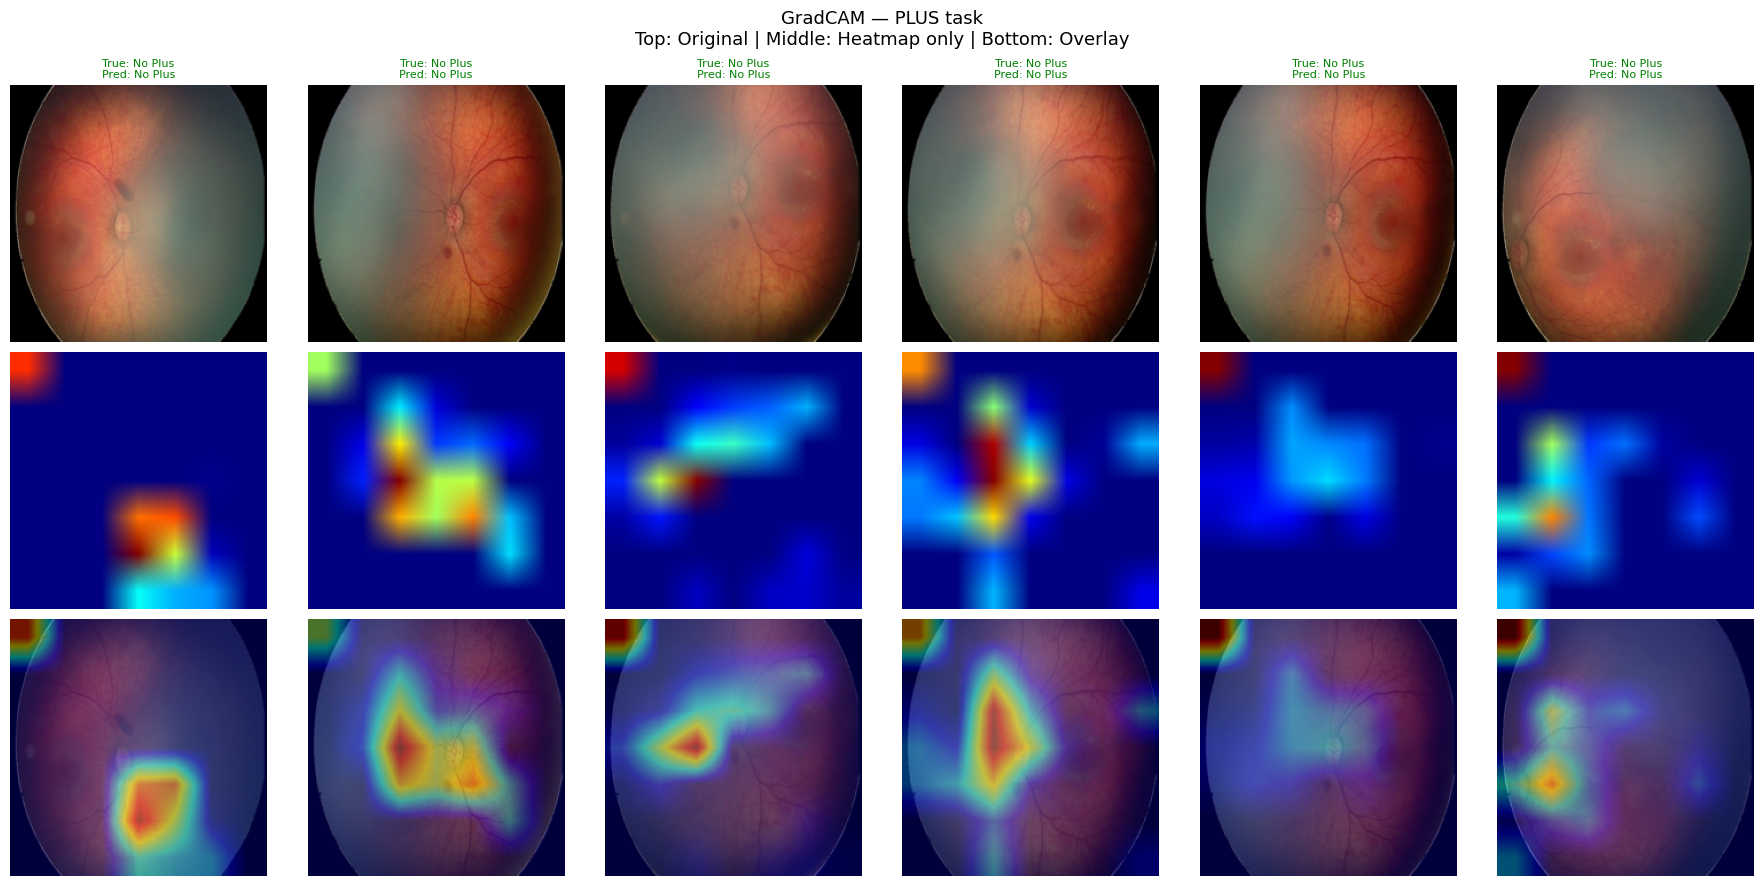

Saved → /kaggle/working/gradcam_plus.png


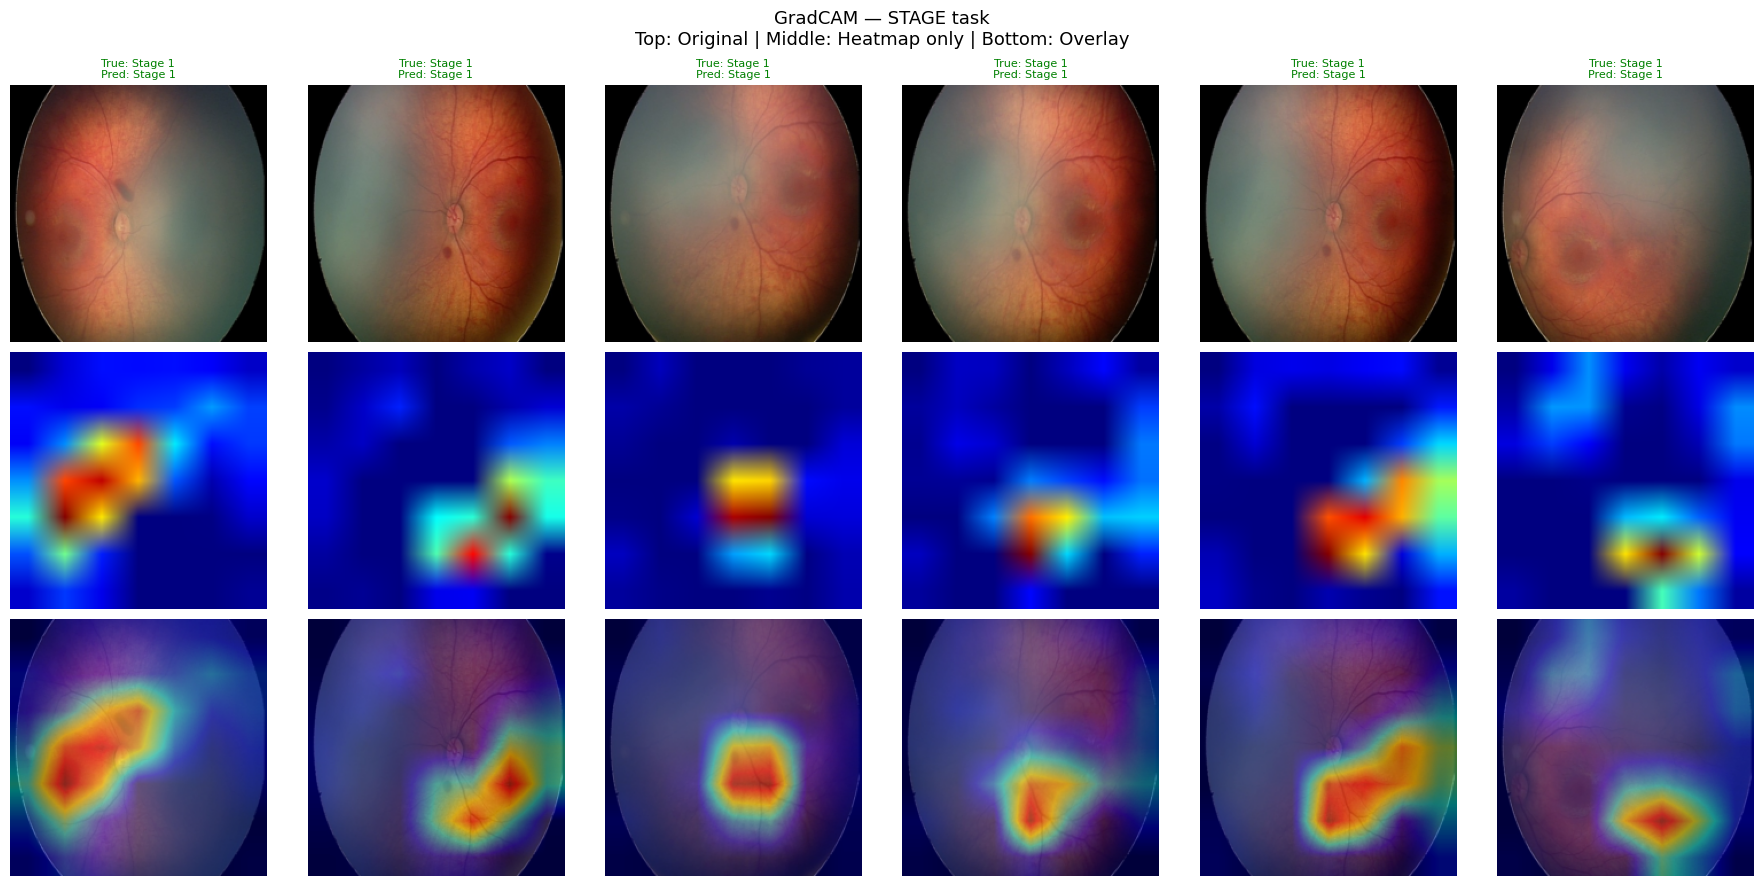

Saved → /kaggle/working/gradcam_stage.png


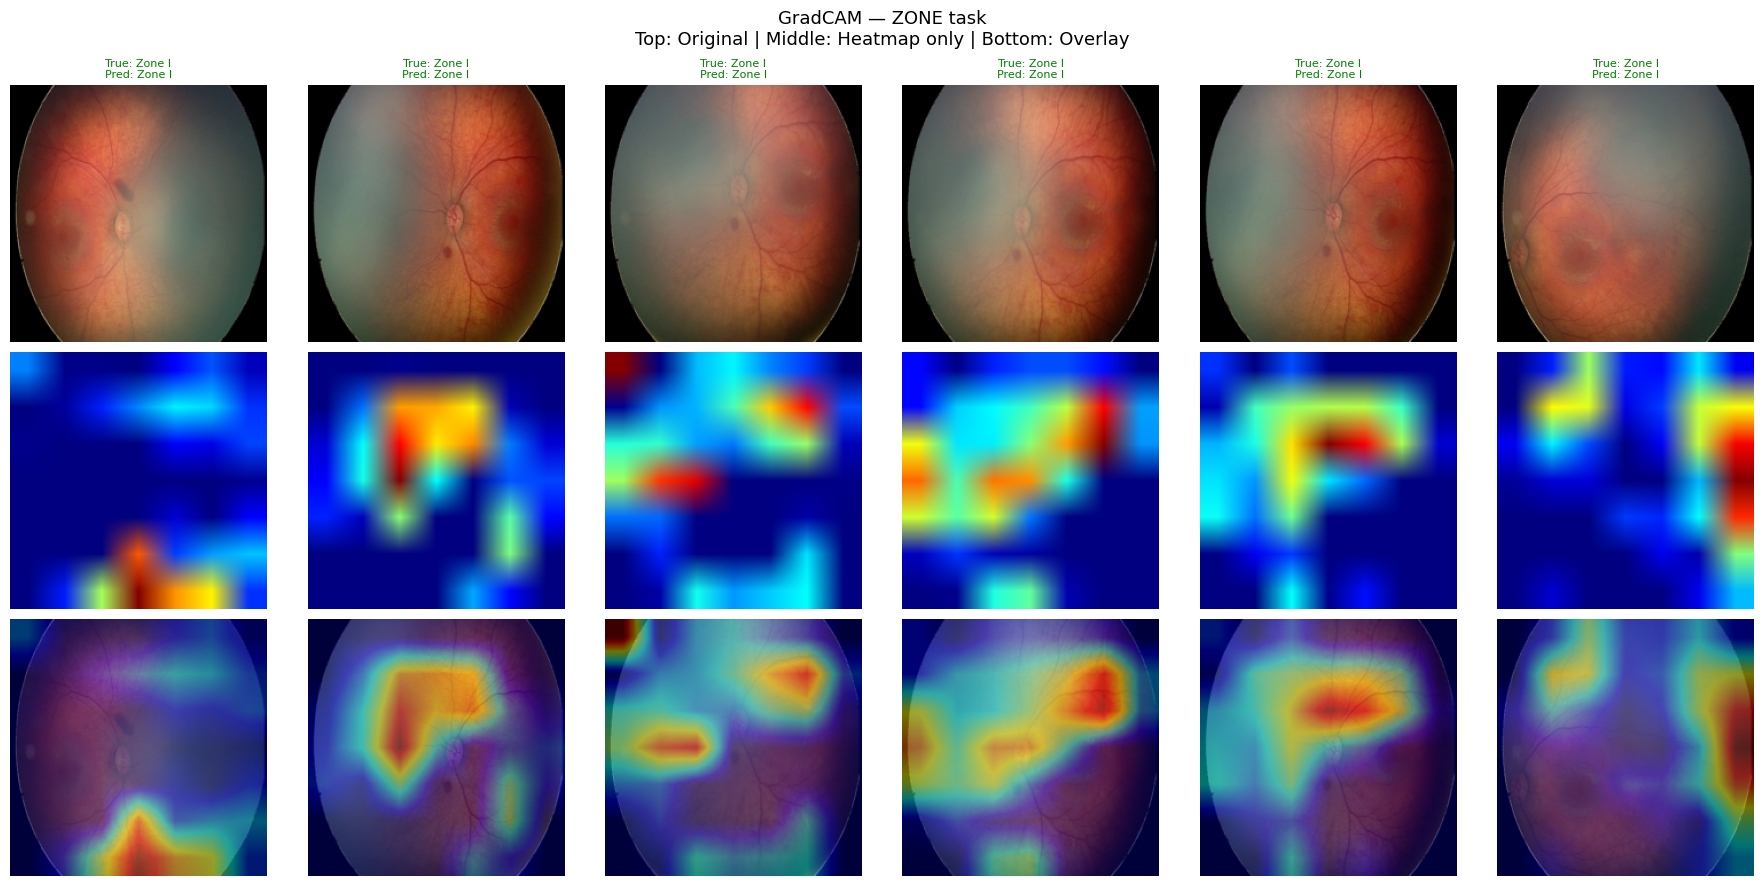

Saved → /kaggle/working/gradcam_zone.png

GradCAM complete.


In [16]:
# ── CELL 16 : GradCAM Visualisation ──────────────────────────────────────────
import cv2
import numpy as np

class GradCAM:
    def __init__(self, model, target_layer):
        self.model  = model
        self.grads  = None
        self.acts   = None
        self.hooks  = []
        h1 = target_layer.register_forward_hook(self._save_acts)
        h2 = target_layer.register_full_backward_hook(self._save_grads)
        self.hooks  = [h1, h2]

    def _save_acts(self, _, __, out):
        self.acts = out.detach()

    def _save_grads(self, _, __, grad_out):
        self.grads = grad_out[0].detach()

    def generate(self, img_tensor, meta_tensor, task='plus', class_idx=None):
        self.model.eval()
        img_tensor  = img_tensor.unsqueeze(0).to(device).requires_grad_(True)
        meta_tensor = meta_tensor.unsqueeze(0).to(device)

        ls, lz, lp  = self.model(img_tensor, meta_tensor)
        task_map    = {'stage': ls, 'zone': lz, 'plus': lp}
        logit       = task_map[task]

        if class_idx is None:
            class_idx = logit.argmax(dim=1).item()

        self.model.zero_grad()
        logit[0, class_idx].backward()

        # Global average pool the gradients
        alpha   = self.grads.mean(dim=[2, 3], keepdim=True)
        cam     = F.relu((alpha * self.acts).sum(dim=1, keepdim=True))
        cam     = cam.squeeze().cpu().numpy()

        # Normalise to 0-1
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

    def remove_hooks(self):
        for h in self.hooks: h.remove()


def overlay_gradcam(img_tensor, cam, alpha=0.45):
    """Overlay CAM heatmap on original image."""
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    # Unnormalise image
    img  = img_tensor.permute(1,2,0).numpy()
    img  = np.clip(img * std + mean, 0, 1)
    img  = (img * 255).astype(np.uint8)

    # Resize CAM to image size
    cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap     = cv2.applyColorMap(
                    (cam_resized * 255).astype(np.uint8),
                    cv2.COLORMAP_JET)
    heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay     = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    return overlay, img


# ── Target layer = last conv block of EfficientNet-B3 ────────────────────────
target_layer = model.backbone.cnn.features[-1]
gradcam      = GradCAM(model, target_layer)

# ── Get one batch from test loader ───────────────────────────────────────────
test_imgs, test_metas, test_sl, test_zl, test_pl = next(iter(test_loader))

# ── Plot GradCAM for each task — 6 samples each ──────────────────────────────
task_configs = [
    ('plus',  test_pl,  ['No Plus','Plus'],
     ['No Plus','Plus']),
    ('stage', test_sl,  ['Stage 0','Stage 1','Stage 2','Stage 3'],
     ['S0','S1','S2','S3']),
    ('zone',  test_zl,  ['Zone I','Zone II','Zone III'],
     ['ZI','ZII','ZIII']),
]

n_samples = 6

for task, true_labels, class_names, short_names in task_configs:
    fig, axes = plt.subplots(3, n_samples, figsize=(18, 9))
    fig.suptitle(
        f'GradCAM — {task.upper()} task\n'
        f'Top: Original | Middle: Heatmap only | Bottom: Overlay',
        fontsize=13)

    for col in range(n_samples):
        img_t  = test_imgs[col].cpu()
        meta_t = test_metas[col].cpu()
        true_l = true_labels[col].item()

        cam, pred_idx = gradcam.generate(img_t, meta_t, task=task)
        overlay, orig = overlay_gradcam(img_t, cam)

        # Heatmap only
        heatmap_only = cv2.applyColorMap(
            (cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap_only = cv2.cvtColor(
            cv2.resize(heatmap_only,
                      (orig.shape[1], orig.shape[0])),
            cv2.COLOR_BGR2RGB)

        # Row 0 — original image
        axes[0, col].imshow(orig)
        axes[0, col].set_title(
            f'True: {class_names[true_l]}\nPred: {class_names[pred_idx]}',
            fontsize=8,
            color='green' if pred_idx == true_l else 'red')
        axes[0, col].axis('off')

        # Row 1 — heatmap only
        axes[1, col].imshow(heatmap_only)
        axes[1, col].axis('off')

        # Row 2 — overlay
        axes[2, col].imshow(overlay)
        axes[2, col].axis('off')

    plt.tight_layout()
    plt.savefig(f'/kaggle/working/gradcam_{task}.png', dpi=150,
                bbox_inches='tight')
    plt.show()
    print(f"Saved → /kaggle/working/gradcam_{task}.png")

gradcam.remove_hooks()
print("\nGradCAM complete.")